<a href="https://colab.research.google.com/github/BADIAMOHAMEDAYMANE/Animal-Classification/blob/main/ImageClassification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Chargement et préparation des données CIFAR-10**


In [6]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Utilisation de : {device}")

# Transformations entraînement : avec data augmentation
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

# Transformations test : SANS augmentation
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

pin = (device.type == 'cuda')

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform_train)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=128,
                                          shuffle=True, num_workers=2, pin_memory=pin)

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform_test)
testloader = torch.utils.data.DataLoader(testset, batch_size=100,
                                         shuffle=False, num_workers=2, pin_memory=pin)

classes = ('plane', 'car', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck')

print(f"Train : {len(trainset)} images | Test : {len(testset)} images")

Utilisation de : cuda:0
Train : 50000 images | Test : 10000 images


# **Visualisation des données d'entraînement**

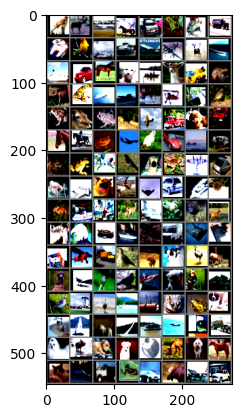

bird  deer  plane horse


In [7]:
def imshow(img):
    img = img / 2 + 0.5     # dé-normalisation pour l'affichage
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

# Récupérer quelques images aléatoires
dataiter = iter(trainloader)
images, labels = next(dataiter)

# Afficher les images
imshow(torchvision.utils.make_grid(images))
# Afficher les labels
print(' '.join(f'{classes[labels[j]]:5s}' for j in range(4)))

# **Architecture du réseau de neurones convolutif**

In [8]:
import torch.nn as nn
import torch.nn.functional as F

class NetV2(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(128 * 8 * 8, 512), nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 10)
        )
    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)

net = NetV2().to(device)

# **Fonctions de perte et optimiseur**

In [13]:
import torch.nn as nn
import torch.optim as optim

criterion = nn.CrossEntropyLoss()  # ← manquait !
optimizer = optim.SGD(net.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

print("✅ criterion, optimizer et scheduler prêts")

✅ criterion, optimizer et scheduler prêts


# **Boucle d'entraînement**

In [14]:
for epoch in range(10):
    running_loss = 0.0

    for i, data in enumerate(trainloader, 0):
        inputs, labels = data[0].to(device), data[1].to(device)

        optimizer.zero_grad()
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        if i % 100 == 99:  # toutes les 100 batches (adapté au batch_size=128)
            print(f'[Epoch {epoch+1}, Batch {i+1:4d}] loss: {running_loss / 100:.3f}')
            running_loss = 0.0

    scheduler.step()  # ✅ une seule fois par epoch

print('Entraînement terminé !')
torch.save(net.state_dict(), './cifar_net.pth')

[Epoch 1, Batch  100] loss: 1.892
[Epoch 1, Batch  200] loss: 1.676
[Epoch 1, Batch  300] loss: 1.574
[Epoch 2, Batch  100] loss: 1.443
[Epoch 2, Batch  200] loss: 1.391
[Epoch 2, Batch  300] loss: 1.344
[Epoch 3, Batch  100] loss: 1.246
[Epoch 3, Batch  200] loss: 1.218
[Epoch 3, Batch  300] loss: 1.149
[Epoch 4, Batch  100] loss: 1.082
[Epoch 4, Batch  200] loss: 1.083
[Epoch 4, Batch  300] loss: 1.050
[Epoch 5, Batch  100] loss: 1.003
[Epoch 5, Batch  200] loss: 0.972
[Epoch 5, Batch  300] loss: 0.962
[Epoch 6, Batch  100] loss: 0.923
[Epoch 6, Batch  200] loss: 0.891
[Epoch 6, Batch  300] loss: 0.906
[Epoch 7, Batch  100] loss: 0.864
[Epoch 7, Batch  200] loss: 0.829
[Epoch 7, Batch  300] loss: 0.838
[Epoch 8, Batch  100] loss: 0.799
[Epoch 8, Batch  200] loss: 0.803
[Epoch 8, Batch  300] loss: 0.791
[Epoch 9, Batch  100] loss: 0.752
[Epoch 9, Batch  200] loss: 0.762
[Epoch 9, Batch  300] loss: 0.765
[Epoch 10, Batch  100] loss: 0.734
[Epoch 10, Batch  200] loss: 0.736
[Epoch 10, B

# **Inférence et visualisation des prédictions**

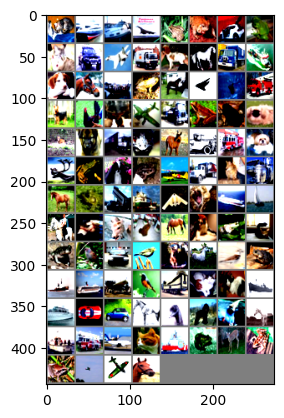

Vérité :  cat   ship  ship  plane
Prédit :  cat   ship  ship  plane


In [16]:
dataiter = iter(testloader)
images, labels = next(dataiter)

# Afficher les images de test (avant de les envoyer sur GPU)
imshow(torchvision.utils.make_grid(images))
print('Vérité : ', ' '.join(f'{classes[labels[j]]:5s}' for j in range(4)))

# ✅ Envoyer images ET labels sur le GPU
images, labels = images.to(device), labels.to(device)

# Faire la prédiction avec le modèle
net.eval()  # ✅ mode évaluation (désactive Dropout, BatchNorm en mode inférence)
with torch.no_grad():  # ✅ désactive le calcul des gradients (plus rapide)
    outputs = net(images)
    _, predicted = torch.max(outputs, 1)

print('Prédit : ', ' '.join(f'{classes[predicted[j].cpu()]:5s}' for j in range(4)))